<a href="https://colab.research.google.com/github/AshSama12/Measurements/blob/master/key_point_vf1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
from pathlib import Path

zip_path = "/content/GMAS KEYPOINT.yolov8 (3).zip"
extract_path = "/content/gmas_keypoint"

if not os.path.exists(zip_path):
    print("ZIP file not found:", zip_path)
else:
    if os.path.exists(extract_path):
        import shutil
        shutil.rmtree(extract_path)

    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("DATASET EXTRACTED")
    print("-----------------")
    print("ZIP:", zip_path)
    print("Extracted to:", extract_path)

    print("\nDATASET STRUCTURE")
    print("-----------------")

    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, "").count(os.sep)
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        subindent = "    " * (level + 1)
        for file in files[:10]:
            print(f"{subindent}{file}")

        if len(files) > 10:
            print(f"{subindent}... {len(files) - 10} more files")

DATASET EXTRACTED
-----------------
ZIP: /content/GMAS KEYPOINT.yolov8 (3).zip
Extracted to: /content/gmas_keypoint

DATASET STRUCTURE
-----------------
gmas_keypoint/
    README.roboflow.txt
    README.dataset.txt
    data.yaml
    train/
        labels/
            90_jpeg.rf.t25V8bHUzsOPPAWs9oMe.txt
            277_jpeg.rf.GmXpTn4ysJBmztPvte40.txt
            405_jpeg.rf.StbN4GWYzS5MFafvEQak.txt
            85_jpeg.rf.hyYfSXNFKWKq7TYvaYLq.txt
            105_jpeg.rf.U0K02KUQgrNfZDkJQcpJ.txt
            269_jpeg.rf.e7EJ3MUDnhxtNzdqHhhu.txt
            84_jpeg.rf.huW7udZWF0cEtiG0yYeO.txt
            298_jpeg.rf.YhwFj4T7UTcqFnTdlwC3.txt
            301_jpeg.rf.Pbfab4WhDysh46AtO54n.txt
            293_jpeg.rf.yR4HTbfCvcUpecc4YVFh.txt
            ... 160 more files
        images/
            306_jpeg.rf.Y9I4bjsBB2CEcG6W7psk.jpeg
            82_jpeg.rf.q7WAwMHV5HmQwBRQnXA4.jpeg
            379_jpeg.rf.rbSwwtCkfqOiCY58QPHW.jpeg
            307_jpeg.rf.IdSNnUcx98enwvYFiyQh.jpeg
           

In [2]:
import os
from pathlib import Path

dataset_path = Path("/content/gmas_keypoint")

print("DATASET ANALYSIS")
print("================")

yaml_path = dataset_path / "data.yaml"

print("\n--- data.yaml ---")
if yaml_path.exists():
    with open(yaml_path, "r") as f:
        print(f.read())
else:
    print("data.yaml not found")


print("\n--- FILE COUNTS ---")

for split in ["train", "valid", "test"]:
    split_path = dataset_path / split

    if not split_path.exists():
        print(f"\n{split}: NOT FOUND")
        continue

    image_path = split_path / "images"
    label_path = split_path / "labels"

    images = []
    labels = []

    if image_path.exists():
        images = [
            f for f in image_path.iterdir()
            if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
        ]

    if label_path.exists():
        labels = [
            f for f in label_path.iterdir()
            if f.suffix.lower() == ".txt"
        ]

    print(f"\n{split.upper()}")
    print("Images :", len(images))
    print("Labels :", len(labels))
    print("Images without labels:", len(set(x.stem for x in images) - set(x.stem for x in labels)))
    print("Labels without images:", len(set(x.stem for x in labels) - set(x.stem for x in images)))


print("\n--- ANNOTATION ANALYSIS ---")

all_label_files = []

for split in ["train", "valid", "test"]:
    label_path = dataset_path / split / "labels"

    if label_path.exists():
        all_label_files.extend(label_path.glob("*.txt"))

print("Total label files:", len(all_label_files))

class_counts = {}
line_lengths = {}
bad_lines = []

for label_file in all_label_files:

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line_number, line in enumerate(lines, 1):

        values = line.split()

        if len(values) == 0:
            continue

        try:
            class_id = int(float(values[0]))
        except:
            bad_lines.append(
                (str(label_file), line_number, "Invalid class ID", line)
            )
            continue

        class_counts[class_id] = class_counts.get(class_id, 0) + 1

        line_length = len(values)
        line_lengths[line_length] = line_lengths.get(line_length, 0) + 1


print("\nCLASS DISTRIBUTION")
print("------------------")

for class_id in sorted(class_counts):
    print(f"Class {class_id}: {class_counts[class_id]} annotations")


print("\nANNOTATION LINE LENGTHS")
print("----------------------")

for length in sorted(line_lengths):
    print(f"{length} values: {line_lengths[length]} lines")


print("\nBAD ANNOTATIONS")
print("---------------")

print("Bad lines:", len(bad_lines))

for item in bad_lines[:20]:
    print(item)


print("\n--- SAMPLE ANNOTATIONS ---")

shown = 0

for label_file in all_label_files:

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if lines:
        print(f"\nFILE: {label_file}")
        for line in lines[:3]:
            print(line)

        shown += 1

    if shown >= 5:
        break

DATASET ANALYSIS

--- data.yaml ---
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 32
names: ['Crotch', 'GUSSET', 'L. HS', 'L.AH', 'L.FBP', 'L.FEP', 'L.FFP', 'L.FW1', 'L.FW2', 'L.HP', 'L.LOE', 'L.NEP', 'L.SNP', 'L.SOE', 'L.SOS', 'L.SP', 'L.SSE', 'R. HS', 'R.AH', 'R.FBP', 'R.FEP', 'R.FFP', 'R.FW1', 'R.FW2', 'R.HP', 'R.LOE', 'R.NEP', 'R.SNP', 'R.SOE', 'R.SOS', 'R.SP', 'R.SSE']

roboflow:
  workspace: computer-vision-3cb8v
  project: gmas-keypoint
  version: dataset
  license: CC BY 4.0
  url: https://universe.roboflow.com/computer-vision-3cb8v/gmas-keypoint/dataset/dataset

--- FILE COUNTS ---

TRAIN
Images : 170
Labels : 170
Images without labels: 0
Labels without images: 0

valid: NOT FOUND

test: NOT FOUND

--- ANNOTATION ANALYSIS ---
Total label files: 170

CLASS DISTRIBUTION
------------------
Class 0: 96 annotations
Class 1: 8 annotations
Class 2: 6 annotations
Class 3: 185 annotations
Class 4: 5 annotations
Class 5: 6 annotations
Class 6: 6 annotations
Class

In [3]:
import os
from pathlib import Path
from PIL import Image

dataset_path = Path("/content/gmas_keypoint")
image_path = dataset_path / "train" / "images"
label_path = dataset_path / "train" / "labels"

class_names = [
    "Crotch", "GUSSET", "L. HS", "L.AH", "L.FBP", "L.FEP",
    "L.FFP", "L.FW1", "L.FW2", "L.HP", "L.LOE", "L.NEP",
    "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE", "R. HS",
    "R.AH", "R.FBP", "R.FEP", "R.FFP", "R.FW1", "R.FW2",
    "R.HP", "R.LOE", "R.NEP", "R.SNP", "R.SOE", "R.SOS",
    "R.SP", "R.SSE"
]

print("KEYPOINT DATASET INSPECTION")
print("============================")

image_files = sorted([
    f for f in image_path.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
])

label_files = sorted(label_path.glob("*.txt"))

print("\nImages:", len(image_files))
print("Labels:", len(label_files))

print("\nIMAGE DIMENSIONS")
print("----------------")

dimension_counts = {}

for img_file in image_files:
    try:
        with Image.open(img_file) as img:
            size = img.size

        dimension_counts[size] = dimension_counts.get(size, 0) + 1

    except Exception as e:
        print("Error:", img_file.name, e)

for size, count in sorted(dimension_counts.items()):
    print(f"{size[0]} x {size[1]} : {count} images")


print("\nBOUNDING BOX SIZE ANALYSIS")
print("--------------------------")

widths = []
heights = []

for label_file in label_files:

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:

        values = line.split()

        if len(values) != 5:
            continue

        class_id = int(values[0])
        x = float(values[1])
        y = float(values[2])
        w = float(values[3])
        h = float(values[4])

        widths.append(w)
        heights.append(h)


if widths and heights:

    print("Total keypoint boxes:", len(widths))

    print("\nWidth:")
    print("Minimum:", min(widths))
    print("Maximum:", max(widths))
    print("Average:", sum(widths) / len(widths))

    print("\nHeight:")
    print("Minimum:", min(heights))
    print("Maximum:", max(heights))
    print("Average:", sum(heights) / len(heights))


print("\nCLASS DETAILS")
print("-------------")

class_stats = {}

for label_file in label_files:

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    classes_in_image = set()

    for line in lines:

        values = line.split()

        if len(values) != 5:
            continue

        class_id = int(values[0])

        if class_id not in class_stats:
            class_stats[class_id] = {
                "annotations": 0,
                "images": set()
            }

        class_stats[class_id]["annotations"] += 1
        class_stats[class_id]["images"].add(label_file.stem)

        classes_in_image.add(class_id)


print(
    f"{'ID':<4}"
    f"{'KEYPOINT':<12}"
    f"{'ANNOTATIONS':<14}"
    f"{'IMAGES':<10}"
)

print("-" * 45)

for class_id in range(len(class_names)):

    if class_id in class_stats:

        annotations = class_stats[class_id]["annotations"]
        images = len(class_stats[class_id]["images"])

    else:

        annotations = 0
        images = 0

    print(
        f"{class_id:<4}"
        f"{class_names[class_id]:<12}"
        f"{annotations:<14}"
        f"{images:<10}"
    )


print("\nANNOTATIONS PER IMAGE")
print("---------------------")

annotation_counts = []

for label_file in label_files:

    with open(label_file, "r") as f:
        count = len([line for line in f if line.strip()])

    annotation_counts.append(count)

print("Minimum:", min(annotation_counts))
print("Maximum:", max(annotation_counts))
print("Average:", sum(annotation_counts) / len(annotation_counts))


print("\nCHECK COMPLETE")

KEYPOINT DATASET INSPECTION

Images: 170
Labels: 170

IMAGE DIMENSIONS
----------------
1200 x 1600 : 34 images
1600 x 1200 : 136 images

BOUNDING BOX SIZE ANALYSIS
--------------------------
Total keypoint boxes: 2849

Width:
Minimum: 0.0
Maximum: 0.026875
Average: 0.007619517184392185

Height:
Minimum: 0.001927
Maximum: 0.03479441666666667
Average: 0.008730845091845092

CLASS DETAILS
-------------
ID  KEYPOINT    ANNOTATIONS   IMAGES    
---------------------------------------------
0   Crotch      96            86        
1   GUSSET      8             8         
2   L. HS       6             6         
3   L.AH        185           165       
4   L.FBP       5             5         
5   L.FEP       6             6         
6   L.FFP       6             6         
7   L.FW1       5             5         
8   L.FW2       5             5         
9   L.HP        138           124       
10  L.LOE       89            78        
11  L.NEP       177           159       
12  L.SNP       16

In [4]:
from pathlib import Path

dataset_path = Path("/content/gmas_keypoint")
label_path = dataset_path / "train" / "labels"

class_names = [
    "Crotch", "GUSSET", "L. HS", "L.AH", "L.FBP", "L.FEP",
    "L.FFP", "L.FW1", "L.FW2", "L.HP", "L.LOE", "L.NEP",
    "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE", "R. HS",
    "R.AH", "R.FBP", "R.FEP", "R.FFP", "R.FW1", "R.FW2",
    "R.HP", "R.LOE", "R.NEP", "R.SNP", "R.SOE", "R.SOS",
    "R.SP", "R.SSE"
]

zero_width = []
zero_height = []

for label_file in sorted(label_path.glob("*.txt")):

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line_number, line in enumerate(lines, 1):

        values = line.split()

        if len(values) != 5:
            continue

        class_id = int(values[0])
        x = float(values[1])
        y = float(values[2])
        w = float(values[3])
        h = float(values[4])

        if w == 0:
            zero_width.append({
                "file": label_file.name,
                "line": line_number,
                "class_id": class_id,
                "class_name": class_names[class_id],
                "x": x,
                "y": y,
                "width": w,
                "height": h
            })

        if h == 0:
            zero_height.append({
                "file": label_file.name,
                "line": line_number,
                "class_id": class_id,
                "class_name": class_names[class_id],
                "x": x,
                "y": y,
                "width": w,
                "height": h
            })


print("ZERO-WIDTH ANNOTATIONS")
print("======================")

print("Total:", len(zero_width))

zero_width_classes = {}

for item in zero_width:
    cid = item["class_id"]

    if cid not in zero_width_classes:
        zero_width_classes[cid] = 0

    zero_width_classes[cid] += 1

for cid in sorted(zero_width_classes):
    print(
        f"Class {cid:2d}  "
        f"{class_names[cid]:8s}  "
        f"Count: {zero_width_classes[cid]}"
    )


print("\nFIRST ZERO-WIDTH ANNOTATIONS")
print("============================")

for item in zero_width[:30]:
    print(
        item["file"],
        "| line:", item["line"],
        "| class:", item["class_id"],
        item["class_name"],
        "| x:", item["x"],
        "| y:", item["y"],
        "| w:", item["width"],
        "| h:", item["height"]
    )


print("\nZERO-HEIGHT ANNOTATIONS")
print("=======================")

print("Total:", len(zero_height))

if len(zero_height) > 0:
    for item in zero_height[:30]:
        print(
            item["file"],
            "| line:", item["line"],
            "| class:", item["class_id"],
            item["class_name"],
            "| x:", item["x"],
            "| y:", item["y"],
            "| w:", item["width"],
            "| h:", item["height"]
        )

ZERO-WIDTH ANNOTATIONS
Total: 1
Class 29  R.SOS     Count: 1

FIRST ZERO-WIDTH ANNOTATIONS
296_jpeg.rf.SBgaPBbFSqxVkFtnsKth.txt | line: 14 | class: 29 R.SOS | x: 0.0 | y: 0.9283336666666666 | w: 0.0 | h: 0.003615083333333333

ZERO-HEIGHT ANNOTATIONS
Total: 0


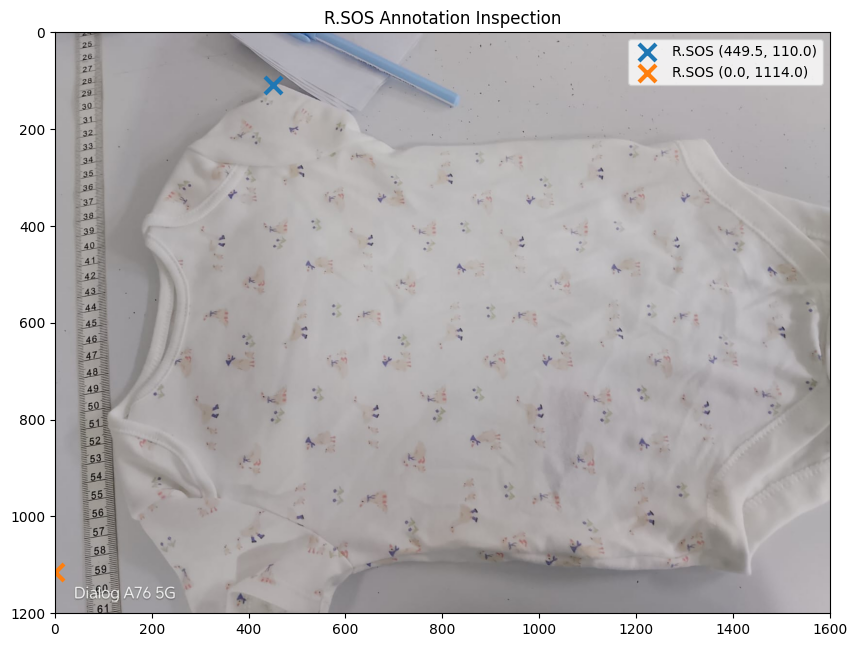

Image: 296_jpeg.rf.SBgaPBbFSqxVkFtnsKth.jpeg
Image size: 1600 x 1200
R.SOS pixel position:
X: 449.512
Y: 109.9938
X: 0.0
Y: 1114.0004


In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = Path("/content/gmas_keypoint")
image_path = dataset_path / "train" / "images"
label_path = dataset_path / "train" / "labels"

target_name = "296_jpeg.rf.SBgaPBbFSqxVkFtnsKth"

image_file = None

for ext in [".jpg", ".jpeg", ".png", ".webp", ".bmp"]:
    candidate = image_path / (target_name + ext)
    if candidate.exists():
        image_file = candidate
        break

if image_file is None:
    print("Image not found")
else:

    image = Image.open(image_file).convert("RGB")

    with open(label_path / (target_name + ".txt"), "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    points = []

    for line in lines:

        values = line.split()

        if len(values) != 5:
            continue

        class_id = int(values[0])
        x = float(values[1])
        y = float(values[2])

        px = x * image.width
        py = y * image.height

        points.append((class_id, px, py))

    plt.figure(figsize=(10, 12))
    plt.imshow(image)

    for class_id, px, py in points:

        if class_id == 29:
            plt.scatter(
                px,
                py,
                s=150,
                marker="x",
                linewidths=3,
                label=f"R.SOS ({px:.1f}, {py:.1f})"
            )

    plt.xlim(0, image.width)
    plt.ylim(image.height, 0)
    plt.title("R.SOS Annotation Inspection")
    plt.legend()
    plt.show()

    print("Image:", image_file.name)
    print("Image size:", image.width, "x", image.height)
    print("R.SOS pixel position:")

    for class_id, px, py in points:
        if class_id == 29:
            print("X:", px)
            print("Y:", py)

In [6]:
from pathlib import Path

dataset_path = Path("/content/gmas_keypoint")
label_path = dataset_path / "train" / "labels"

target_file = label_path / "296_jpeg.rf.SBgaPBbFSqxVkFtnsKth.txt"

if not target_file.exists():
    print("Target label file not found:", target_file)
else:

    with open(target_file, "r") as f:
        original_lines = [line.strip() for line in f if line.strip()]

    cleaned_lines = []

    removed = []

    for line in original_lines:

        values = line.split()

        if len(values) == 5:

            class_id = int(values[0])
            x = float(values[1])
            y = float(values[2])
            w = float(values[3])
            h = float(values[4])

            if class_id == 29 and x == 0.0 and w == 0.0:
                removed.append(line)
                continue

        cleaned_lines.append(line)

    with open(target_file, "w") as f:
        for line in cleaned_lines:
            f.write(line + "\n")

    print("CLEANUP COMPLETE")
    print("================")

    print("File:", target_file.name)
    print("Original annotations:", len(original_lines))
    print("Remaining annotations:", len(cleaned_lines))
    print("Removed annotations:", len(removed))

    print("\nREMOVED:")
    for line in removed:
        print(line)


print("\nFINAL ANNOTATION CHECK")
print("======================")

zero_width = []
zero_height = []

for label_file in sorted(label_path.glob("*.txt")):

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line_number, line in enumerate(lines, 1):

        values = line.split()

        if len(values) != 5:
            continue

        class_id = int(values[0])
        x = float(values[1])
        y = float(values[2])
        w = float(values[3])
        h = float(values[4])

        if w == 0:
            zero_width.append(
                (label_file.name, line_number, class_id, x, y, w, h)
            )

        if h == 0:
            zero_height.append(
                (label_file.name, line_number, class_id, x, y, w, h)
            )

print("Zero-width annotations:", len(zero_width))
print("Zero-height annotations:", len(zero_height))

CLEANUP COMPLETE
File: 296_jpeg.rf.SBgaPBbFSqxVkFtnsKth.txt
Original annotations: 14
Remaining annotations: 13
Removed annotations: 1

REMOVED:
29 0 0.9283336666666666 0 0.003615083333333333

FINAL ANNOTATION CHECK
Zero-width annotations: 0
Zero-height annotations: 0


In [8]:
import os
import shutil
import random
from pathlib import Path
from collections import defaultdict

source = Path("/content/gmas_keypoint")
source_images = source / "train" / "images"
source_labels = source / "train" / "labels"

output = Path("/content/GMAS_split")

if output.exists():
    shutil.rmtree(output)

for split in ["train", "valid", "test"]:
    (output / split / "images").mkdir(parents=True, exist_ok=True)
    (output / split / "labels").mkdir(parents=True, exist_ok=True)

image_files = sorted(
    list(source_images.glob("*.jpg")) +
    list(source_images.glob("*.jpeg")) +
    list(source_images.glob("*.png"))
)

image_classes = {}

for image_file in image_files:

    label_file = source_labels / f"{image_file.stem}.txt"

    classes = set()

    if label_file.exists():
        with open(label_file, "r") as f:
            for line in f:
                values = line.strip().split()

                if len(values) == 5:
                    classes.add(int(values[0]))

    image_classes[image_file] = classes


random.seed(42)

class_images = defaultdict(list)

for image_file, classes in image_classes.items():
    for cls in classes:
        class_images[cls].append(image_file)


valid_set = set()
test_set = set()


for cls in sorted(class_images):

    images = class_images[cls].copy()
    random.shuffle(images)

    if len(images) >= 10:

        valid_count = max(1, round(len(images) * 0.20))
        test_count = max(1, round(len(images) * 0.10))

        for img in images:
            if len(valid_set) < valid_count and img not in test_set:
                valid_set.add(img)

        for img in images:
            if len(test_set) < test_count and img not in valid_set:
                test_set.add(img)


target_valid = round(len(image_files) * 0.20)
target_test = round(len(image_files) * 0.10)

remaining = [
    img for img in image_files
    if img not in valid_set and img not in test_set
]

random.shuffle(remaining)


while len(valid_set) < target_valid and remaining:

    valid_set.add(remaining.pop())


while len(test_set) < target_test and remaining:

    test_set.add(remaining.pop())


train_set = [
    img for img in image_files
    if img not in valid_set and img not in test_set
]


def copy_dataset(file_list, split):

    for image_file in file_list:

        label_file = source_labels / f"{image_file.stem}.txt"

        shutil.copy2(
            image_file,
            output / split / "images" / image_file.name
        )

        if label_file.exists():

            shutil.copy2(
                label_file,
                output / split / "labels" / label_file.name
            )


copy_dataset(train_set, "train")
copy_dataset(valid_set, "valid")
copy_dataset(test_set, "test")


print("DATASET SPLIT COMPLETE")
print("======================")

print("Total images :", len(image_files))
print("Training     :", len(train_set))
print("Validation   :", len(valid_set))
print("Testing      :", len(test_set))

print("\nCLASS DISTRIBUTION")
print("==================")

for cls in range(32):

    train_count = sum(
        cls in image_classes[img]
        for img in train_set
    )

    valid_count = sum(
        cls in image_classes[img]
        for img in valid_set
    )

    test_count = sum(
        cls in image_classes[img]
        for img in test_set
    )

    print(
        f"Class {cls:2d} | "
        f"Train: {train_count:3d} | "
        f"Valid: {valid_count:3d} | "
        f"Test: {test_count:3d}"
    )

DATASET SPLIT COMPLETE
Total images : 170
Training     : 119
Validation   : 34
Testing      : 17

CLASS DISTRIBUTION
Class  0 | Train:  50 | Valid:  23 | Test:  13
Class  1 | Train:   4 | Valid:   4 | Test:   0
Class  2 | Train:   2 | Valid:   4 | Test:   0
Class  3 | Train: 115 | Valid:  34 | Test:  16
Class  4 | Train:   4 | Valid:   0 | Test:   1
Class  5 | Train:   2 | Valid:   4 | Test:   0
Class  6 | Train:   4 | Valid:   1 | Test:   1
Class  7 | Train:   1 | Valid:   4 | Test:   0
Class  8 | Train:   1 | Valid:   4 | Test:   0
Class  9 | Train:  81 | Valid:  27 | Test:  16
Class 10 | Train:  48 | Valid:  21 | Test:   9
Class 11 | Train: 112 | Valid:  32 | Test:  15
Class 12 | Train: 107 | Valid:  30 | Test:  15
Class 13 | Train:  96 | Valid:  28 | Test:  16
Class 14 | Train:  96 | Valid:  28 | Test:  13
Class 15 | Train: 112 | Valid:  31 | Test:  15
Class 16 | Train:  80 | Valid:  27 | Test:  16
Class 17 | Train:   1 | Valid:   4 | Test:   0
Class 18 | Train: 108 | Valid:  34 | 

In [9]:
from pathlib import Path
import yaml

dataset_path = Path("/content/GMAS_split")

data = {
    "train": str(dataset_path / "train" / "images"),
    "val": str(dataset_path / "valid" / "images"),
    "test": str(dataset_path / "test" / "images"),
    "nc": 32,
    "names": [
        "Crotch",
        "GUSSET",
        "L.HS",
        "L.AH",
        "L.FBP",
        "L.FEP",
        "L.FFP",
        "L.FW1",
        "L.FW2",
        "L.HP",
        "L.LOE",
        "L.NEP",
        "L.SNP",
        "L.SOE",
        "L.SOS",
        "L.SP",
        "L.SSE",
        "R.HS",
        "R.AH",
        "R.FBP",
        "R.FEP",
        "R.FFP",
        "R.FW1",
        "R.FW2",
        "R.HP",
        "R.LOE",
        "R.NEP",
        "R.SNP",
        "R.SOE",
        "R.SOS",
        "R.SP",
        "R.SSE"
    ]
}

yaml_path = dataset_path / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("DATA.YAML CREATED")
print("=================")
print(yaml_path)

print("\nCONTENT")
print("=======")

with open(yaml_path, "r") as f:
    print(f.read())

DATA.YAML CREATED
/content/GMAS_split/data.yaml

CONTENT
train: /content/GMAS_split/train/images
val: /content/GMAS_split/valid/images
test: /content/GMAS_split/test/images
nc: 32
names:
- Crotch
- GUSSET
- L.HS
- L.AH
- L.FBP
- L.FEP
- L.FFP
- L.FW1
- L.FW2
- L.HP
- L.LOE
- L.NEP
- L.SNP
- L.SOE
- L.SOS
- L.SP
- L.SSE
- R.HS
- R.AH
- R.FBP
- R.FEP
- R.FFP
- R.FW1
- R.FW2
- R.HP
- R.LOE
- R.NEP
- R.SNP
- R.SOE
- R.SOS
- R.SP
- R.SSE



In [10]:
!pip install -q ultralytics

from ultralytics import YOLO
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

model = YOLO("yolov8n.pt")

print("MODEL LOADED")
print("Dataset:", "/content/GMAS_split/data.yaml")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.164
MODEL LOADED
Dataset: /content/GMAS_split/data.yaml


In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.val(
    data="/content/GMAS_split/data.yaml",
    split="val",
    imgsz=1280,
    batch=4,
    plots=False
)

print("\nDATASET VALIDATION COMPLETE")
print("===========================")
print("Images:", results.images)
print("Instances:", results.box.image_count if hasattr(results, "box") else "N/A")

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1727.4±324.0 MB/s, size: 160.2 KB)
val: Scanning /content/GMAS_split/valid/labels... 34 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 34/34 1.3Kit/s 0.0s
val: New cache created: /content/GMAS_split/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 5.1it/s 1.8s
                   all         34        658          0          0          0          0
                person         23         25          0          0          0          0
               bicycle          4          4          0          0          0          0
                   car          4          4          0          0          0          0
            motorcycle         34         43          0          0          0   

AttributeError: 'DetMetrics' object has no attribute 'images'. See valid attributes below.
Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

Attributes:
    names (dict[int, str]): A dictionary of class names.
    box (Metric): An instance of the Metric class for storing detection results.
    speed (dict[str, float]): A dictionary for storing execution times of different parts of the detection process.
    stats (dict[str, list]): A dictionary containing lists for true positives, confidence scores, predicted classes,
        target classes, and target images.
    nt_per_class (np.ndarray): Number of targets per class.
    nt_per_image (np.ndarray): Number of images containing each class.

Methods:
    update_stats: Update statistics by appending new values to existing stat collections.
    process: Process predicted results for object detection and update metrics.
    clear_stats: Clear the stored statistics.
    keys: Return a

In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")

print("MODEL CREATED")
print("================")

print("Number of classes:", model.model.nc)
print("Class names:")

for i, name in enumerate(model.names):
    print(i, name)

MODEL CREATED


AttributeError: 'DetectionModel' object has no attribute 'nc'

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")

model.train(
    data="/content/GMAS_split/data.yaml",
    epochs=1,
    imgsz=640,
    batch=4,
    device=0,
    workers=2,
    verbose=True
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GMAS_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e66d18c0050>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.0

In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/GMAS_split/data.yaml",
    epochs=100,
    imgsz=1280,
    batch=4,
    device=0,
    workers=2,
    patience=25,
    project="/content/GMAS_training",
    name="gmas_keypoint_v1",
    pretrained=True,
    cache=False,
    plots=True,
    verbose=True
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GMAS_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gmas_keypoint_v1, nbs=64, nms=None, opset=None, optimize=F

In [15]:
from ultralytics import YOLO
import os

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

results = model.predict(
    source="/content/GMAS_split/valid/images",
    imgsz=1280,
    conf=0.10,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/content/GMAS_predictions",
    name="validation",
    max_det=100
)

print("Prediction complete.")
print("Saved to: /content/GMAS_predictions/validation")


image 1/34 /content/GMAS_split/valid/images/154_jpeg.rf.QpN1irjvuAAaYPNFnNfg.jpeg: 960x1280 5 L.AHs, 1 L.LOE, 1 L.SOS, 2 L.SSEs, 1 R.AH, 1 R.LOE, 14.8ms
image 2/34 /content/GMAS_split/valid/images/207_jpeg.rf.dyQxJgT0wKmZOM3ih9SN.jpeg: 960x1280 1 L.AH, 3 L.LOEs, 3 L.SPs, 3 L.SSEs, 1 R.AH, 3 R.HPs, 2 R.LOEs, 1 R.SP, 1 R.SSE, 14.8ms
image 3/34 /content/GMAS_split/valid/images/216_jpeg.rf.1vDHw0tjkqnZOVrpLLJL.jpeg: 960x1280 1 L.SOS, 2 L.SPs, 1 R.SOS, 14.7ms
image 4/34 /content/GMAS_split/valid/images/228_jpeg.rf.k1L1JxuyQfLD1rM0Q1B6.jpeg: 960x1280 1 L.AH, 1 L.NEP, 1 L.SNP, 1 R.LOE, 1 R.SOS, 14.7ms
image 5/34 /content/GMAS_split/valid/images/242_jpeg.rf.w6mB1v51NXVNiuWH650p.jpeg: 960x1280 3 L.HPs, 1 L.SOE, 2 L.SOSs, 1 L.SP, 3 L.SSEs, 4 R.LOEs, 14.7ms
image 6/34 /content/GMAS_split/valid/images/272_jpeg.rf.AwYBs4MM5QudoQvKfSc9.jpeg: 960x1280 1 L.AH, 1 L.HP, 1 L.LOE, 1 L.SNP, 3 L.SOEs, 6 L.SPs, 3 L.SSEs, 1 R.AH, 3 R.HPs, 4 R.LOEs, 1 R.SOE, 2 R.SOSs, 1 R.SP, 1 R.SSE, 14.7ms
image 7/34 /conte

In [16]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded:", filename)

Saving 410.jpeg to 410.jpeg
Uploaded: 410.jpeg


In [17]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

results = model.predict(
    source="/content/410.jpeg",
    imgsz=1280,
    conf=0.10,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/content/GMAS_test",
    name="410",
    max_det=100
)

result = results[0]

print("Detected keypoints:")
for box in result.boxes:
    cls_id = int(box.cls[0])
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    print(f"{model.names[cls_id]:8s}  x={cx:.1f}  y={cy:.1f}  conf={confidence:.3f}")

print("\nTotal detections:", len(result.boxes))
print("Saved prediction:", "/content/GMAS_test/410")


image 1/1 /content/410.jpeg: 1280x960 2 L.AHs, 1 L.HP, 1 L.LOE, 2 L.SOEs, 1 L.SOS, 1 R.SOE, 1 R.SOS, 1 R.SP, 4 R.SSEs, 16.8ms
Speed: 7.5ms preprocess, 16.8ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 960)
Results saved to /content/GMAS_test/410
1 label saved to /content/GMAS_test/410/labels
Detected keypoints:
R.SSE     x=1068.0  y=1095.0  conf=0.581
L.SOE     x=1111.2  y=552.8  conf=0.365
R.SOS     x=1143.8  y=340.7  conf=0.325
R.SOE     x=1110.5  y=553.2  conf=0.260
R.SSE     x=1066.6  y=1093.4  conf=0.248
L.SOS     x=117.8  y=1023.8  conf=0.241
L.LOE     x=298.2  y=1503.9  conf=0.186
L.AH      x=1023.4  y=587.9  conf=0.179
R.SP      x=996.6  y=215.9  conf=0.150
R.SSE     x=1111.1  y=551.7  conf=0.148
L.SOE     x=183.8  y=584.0  conf=0.147
L.AH      x=1025.4  y=587.8  conf=0.134
L.HP      x=1031.7  y=1026.4  conf=0.134
R.SSE     x=1066.9  y=1097.9  conf=0.106

Total detections: 14
Saved prediction: /content/GMAS_test/410


In [18]:
!pip -q install gradio

import gradio as gr
from ultralytics import YOLO
from PIL import Image

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

def predict(image, confidence):
    if image is None:
        return None, []

    results = model.predict(
        source=image,
        imgsz=1280,
        conf=confidence,
        max_det=100,
        verbose=False
    )

    result = results[0]
    annotated = result.plot(labels=True, conf=True, boxes=True)

    detections = []

    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        detections.append([
            model.names[cls_id],
            round(conf, 3),
            round(cx, 1),
            round(cy, 1)
        ])

    detections.sort(key=lambda x: x[0])

    return Image.fromarray(annotated), detections


demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Image(type="pil", label="Garment Image"),
        gr.Slider(
            minimum=0.05,
            maximum=0.90,
            value=0.10,
            step=0.05,
            label="Confidence Threshold"
        )
    ],
    outputs=[
        gr.Image(label="Detected Measurement Points"),
        gr.Dataframe(
            headers=["Keypoint", "Confidence", "X", "Y"],
            datatype=["str", "number", "number", "number"],
            label="Detected Keypoints"
        )
    ],
    title="GMAS - Garment Measurement Keypoint Detection",
    description="Upload a garment image to detect measurement keypoints."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6cbcc198a18752c573.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
from ultralytics import YOLO
import math

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

def get_best_points(image_path, conf=0.10):
    results = model.predict(
        source=image_path,
        imgsz=1280,
        conf=conf,
        max_det=100,
        verbose=False
    )

    result = results[0]
    points = {}

    for box in result.boxes:
        cls_id = int(box.cls[0])
        name = model.names[cls_id]
        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        if name not in points or confidence > points[name]["conf"]:
            points[name] = {
                "x": cx,
                "y": cy,
                "conf": confidence
            }

    return points


def distance(points, p1, p2):
    if p1 not in points or p2 not in points:
        return None

    x1 = points[p1]["x"]
    y1 = points[p1]["y"]
    x2 = points[p2]["x"]
    y2 = points[p2]["y"]

    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


points = get_best_points("/content/410.jpeg")

measurements = {
    "Back Neck Width": distance(points, "L.SNP", "R.SNP"),
    "Back Neck Edge Width": distance(points, "L.NEP", "R.NEP"),
    "Front Length": distance(points, "L.SNP", "Crotch"),
    "Left Sleeve Open": distance(points, "L.SOS", "L.SOE"),
    "Right Sleeve Open": distance(points, "R.SOS", "R.SOE"),
    "Left Sleeve Length": distance(points, "L.SP", "L.SOS"),
    "Right Sleeve Length": distance(points, "R.SP", "R.SOS"),
    "Left Side Seam": distance(points, "L.AH", "L.SSE"),
    "Right Side Seam": distance(points, "R.AH", "R.SSE"),
    "Leg Open Left": distance(points, "L.SSE", "L.LOE"),
    "Leg Open Right": distance(points, "R.SSE", "R.LOE"),
    "Chest": distance(points, "L.AH", "R.AH"),
    "Hip": distance(points, "L.SSE", "R.SSE")
}

print("Detected Points")
print("=" * 50)

for name, p in points.items():
    print(f"{name:10s} X={p['x']:.1f}  Y={p['y']:.1f}  Conf={p['conf']:.3f}")

print("\nMeasurements (pixels)")
print("=" * 50)

for name, value in measurements.items():
    if value is None:
        print(f"{name:25s} NOT DETECTED")
    else:
        print(f"{name:25s} {value:.2f} px")

Detected Points
R.SSE      X=1068.0  Y=1095.0  Conf=0.581
L.SOE      X=1111.2  Y=552.8  Conf=0.365
R.SOS      X=1143.8  Y=340.7  Conf=0.325
R.SOE      X=1110.5  Y=553.2  Conf=0.260
L.SOS      X=117.8  Y=1023.8  Conf=0.241
L.LOE      X=298.2  Y=1503.9  Conf=0.186
L.AH       X=1023.4  Y=587.9  Conf=0.179
R.SP       X=996.6  Y=215.9  Conf=0.150
L.HP       X=1031.7  Y=1026.4  Conf=0.134

Measurements (pixels)
Back Neck Width           NOT DETECTED
Back Neck Edge Width      NOT DETECTED
Front Length              NOT DETECTED
Left Sleeve Open          1099.46 px
Right Sleeve Open         215.13 px
Left Sleeve Length        NOT DETECTED
Right Sleeve Length       192.98 px
Left Side Seam            NOT DETECTED
Right Side Seam           NOT DETECTED
Leg Open Left             NOT DETECTED
Leg Open Right            NOT DETECTED
Chest                     NOT DETECTED
Hip                       NOT DETECTED


In [20]:
import gradio as gr
import math
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

MEASUREMENTS = {
    "Back Neck Width": ("L.SNP", "R.SNP"),
    "Back Neck Edge Width": ("L.NEP", "R.NEP"),
    "Front Length": ("L.SNP", "Crotch"),
    "Left Sleeve Open": ("L.SOS", "L.SOE"),
    "Right Sleeve Open": ("R.SOS", "R.SOE"),
    "Left Sleeve Length": ("L.SP", "L.SOS"),
    "Right Sleeve Length": ("R.SP", "R.SOS"),
    "Left Side Seam": ("L.AH", "L.SSE"),
    "Right Side Seam": ("R.AH", "R.SSE"),
    "Left Leg Open": ("L.SSE", "L.LOE"),
    "Right Leg Open": ("R.SSE", "R.LOE"),
    "Chest": ("L.AH", "R.AH"),
    "Hip": ("L.SSE", "R.SSE")
}


def detect_points(image, confidence):
    results = model.predict(
        source=image,
        imgsz=1280,
        conf=confidence,
        max_det=100,
        verbose=False
    )

    result = results[0]
    points = {}

    for box in result.boxes:
        cls_id = int(box.cls[0])
        name = model.names[cls_id]
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        if name not in points or conf > points[name]["conf"]:
            points[name] = {
                "x": cx,
                "y": cy,
                "conf": conf
            }

    return result, points


def calculate_distance(points, p1, p2):
    if p1 not in points or p2 not in points:
        return None

    x1, y1 = points[p1]["x"], points[p1]["y"]
    x2, y2 = points[p2]["x"], points[p2]["y"]

    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


def predict(image, confidence):

    if image is None:
        return None, []

    result, points = detect_points(image, confidence)

    annotated = Image.fromarray(result.plot(labels=True, conf=True))
    draw = ImageDraw.Draw(annotated)

    measurement_rows = []

    for measurement, (p1, p2) in MEASUREMENTS.items():

        value = calculate_distance(points, p1, p2)

        if value is None:
            missing = []

            if p1 not in points:
                missing.append(p1)

            if p2 not in points:
                missing.append(p2)

            measurement_rows.append([
                measurement,
                p1,
                p2,
                "NOT DETECTED",
                ", ".join(missing)
            ])

        else:
            x1, y1 = points[p1]["x"], points[p1]["y"]
            x2, y2 = points[p2]["x"], points[p2]["y"]

            draw.line(
                [(x1, y1), (x2, y2)],
                width=4
            )

            measurement_rows.append([
                measurement,
                p1,
                p2,
                round(value, 2),
                ""
            ])

    return annotated, measurement_rows


demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Image(
            type="pil",
            label="Garment Image"
        ),
        gr.Slider(
            minimum=0.05,
            maximum=0.90,
            value=0.10,
            step=0.05,
            label="Confidence Threshold"
        )
    ],
    outputs=[
        gr.Image(
            label="Detected Points & Measurement Lines"
        ),
        gr.Dataframe(
            headers=[
                "Measurement",
                "Point 1",
                "Point 2",
                "Pixels",
                "Missing Points"
            ],
            datatype=[
                "str",
                "str",
                "str",
                "number",
                "str"
            ],
            label="Garment Measurements"
        )
    ],
    title="GMAS - Automated Garment Measurement",
    description="Detect garment measurement points and calculate distances."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://618fcb567f63ace679.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
from pathlib import Path
from collections import defaultdict

labels_dir = Path("/content/GMAS_split/train/labels")

body_classes = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

image_counts = defaultdict(set)
annotation_counts = defaultdict(int)

for label_file in labels_dir.glob("*.txt"):
    for line in label_file.read_text().splitlines():
        parts = line.strip().split()

        if len(parts) < 5:
            continue

        cls = int(parts[0])

        if cls in body_classes:
            image_counts[cls].add(label_file.stem)
            annotation_counts[cls] += 1

print("BODY-SUIT KEYPOINT DATASET CHECK")
print("=" * 70)
print(f"{'Class':<8} {'Keypoint':<12} {'Images':<10} {'Annotations':<12}")
print("-" * 70)

for cls, name in body_classes.items():
    print(
        f"{cls:<8} "
        f"{name:<12} "
        f"{len(image_counts[cls]):<10} "
        f"{annotation_counts[cls]:<12}"
    )

print("=" * 70)

total_images = set()

for cls in body_classes:
    total_images.update(image_counts[cls])

print(f"Images containing at least one body-suit point: {len(total_images)}")
print(f"Total body-suit annotations: {sum(annotation_counts.values())}")

BODY-SUIT KEYPOINT DATASET CHECK
Class    Keypoint     Images     Annotations 
----------------------------------------------------------------------
0        Crotch       50         55          
3        L.AH         115        122         
9        L.HP         81         87          
10       L.LOE        48         53          
11       L.NEP        112        119         
12       L.SNP        107        115         
13       L.SOE        96         102         
14       L.SOS        96         100         
15       L.SP         112        121         
16       L.SSE        80         86          
18       R.AH         108        115         
24       R.HP         78         81          
25       R.LOE        53         59          
26       R.NEP        109        117         
27       R.SNP        95         99          
28       R.SOE        82         86          
29       R.SOS        94         100         
30       R.SP         103        110         
31       R.SSE        

In [22]:
from pathlib import Path
from collections import defaultdict

labels_dir = Path("/content/GMAS_split/train/labels")

body_classes = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

duplicates = []

for label_file in labels_dir.glob("*.txt"):

    class_counts = defaultdict(int)

    for line in label_file.read_text().splitlines():
        parts = line.strip().split()

        if len(parts) < 5:
            continue

        cls = int(parts[0])

        if cls in body_classes:
            class_counts[cls] += 1

    for cls, count in class_counts.items():
        if count > 1:
            duplicates.append({
                "image": label_file.stem,
                "class": cls,
                "keypoint": body_classes[cls],
                "count": count
            })

print("DUPLICATE BODY-SUIT KEYPOINT CHECK")
print("=" * 70)

if not duplicates:
    print("No duplicate keypoints found.")
else:
    print(f"Images/keypoints with duplicates: {len(duplicates)}")
    print()

    for item in duplicates:
        print(
            f"{item['image']:<45} "
            f"{item['keypoint']:<10} "
            f"{item['count']} annotations"
        )

print("=" * 70)

duplicate_total = sum(item["count"] - 1 for item in duplicates)

print("Extra duplicate annotations:", duplicate_total)

DUPLICATE BODY-SUIT KEYPOINT CHECK
Images/keypoints with duplicates: 86

434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              R.NEP      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              L.SNP      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              R.SNP      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              L.SP       3 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              L.SOS      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              L.SOE      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              L.AH       2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              L.HP       2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              L.SSE      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              R.SP       2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              R.SOS      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              R.SOE      2 annotations
434_jpeg.rf.EhrbvB2HOIZWzF10rbvL              R.AH       2 annotations
428_

In [23]:
from pathlib import Path
from collections import defaultdict, Counter

labels_dir = Path("/content/GMAS_split/train/labels")

body_classes = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

duplicate_counts = Counter()
duplicate_images = set()
extra_annotations = 0

for label_file in labels_dir.glob("*.txt"):

    counts = defaultdict(int)

    for line in label_file.read_text().splitlines():
        parts = line.strip().split()

        if len(parts) < 5:
            continue

        cls = int(parts[0])

        if cls in body_classes:
            counts[cls] += 1

    for cls, count in counts.items():
        if count > 1:
            duplicate_counts[cls] += 1
            duplicate_images.add(label_file.stem)
            extra_annotations += count - 1

print("DUPLICATE SUMMARY")
print("=" * 60)

print("Images containing duplicate keypoints:", len(duplicate_images))
print("Keypoint types having duplicates:", len(duplicate_counts))
print("Extra duplicate annotations:", extra_annotations)

print("\nDuplicates by keypoint")
print("-" * 60)

for cls in sorted(duplicate_counts):
    print(
        f"{body_classes[cls]:10s} : "
        f"{duplicate_counts[cls]} images"
    )

print("=" * 60)

DUPLICATE SUMMARY
Images containing duplicate keypoints: 11
Keypoint types having duplicates: 19
Extra duplicate annotations: 112

Duplicates by keypoint
------------------------------------------------------------
Crotch     : 3 images
L.AH       : 5 images
L.HP       : 5 images
L.LOE      : 3 images
L.NEP      : 5 images
L.SNP      : 6 images
L.SOE      : 5 images
L.SOS      : 3 images
L.SP       : 7 images
L.SSE      : 4 images
R.AH       : 6 images
R.HP       : 2 images
R.LOE      : 4 images
R.NEP      : 7 images
R.SNP      : 4 images
R.SOE      : 3 images
R.SOS      : 5 images
R.SP       : 6 images
R.SSE      : 3 images


In [24]:
from pathlib import Path
from collections import defaultdict
import math

labels_dir = Path("/content/GMAS_split/train/labels")

body_classes = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

duplicates_found = 0

for label_file in sorted(labels_dir.glob("*.txt")):

    class_points = defaultdict(list)

    for line in label_file.read_text().splitlines():

        parts = line.strip().split()

        if len(parts) < 5:
            continue

        cls = int(parts[0])

        if cls not in body_classes:
            continue

        x = float(parts[1])
        y = float(parts[2])

        class_points[cls].append((x, y))

    for cls, points in class_points.items():

        if len(points) <= 1:
            continue

        duplicates_found += 1

        print(f"\nIMAGE: {label_file.stem}")
        print(f"KEYPOINT: {body_classes[cls]}")
        print(f"ANNOTATIONS: {len(points)}")

        for i, (x, y) in enumerate(points, 1):
            print(
                f"  Point {i}: "
                f"x={x:.6f}, y={y:.6f}"
            )

        for i in range(len(points)):
            for j in range(i + 1, len(points)):

                x1, y1 = points[i]
                x2, y2 = points[j]

                distance = math.sqrt(
                    (x2 - x1) ** 2 +
                    (y2 - y1) ** 2
                )

                print(
                    f"  Distance Point {i+1} ↔ Point {j+1}: "
                    f"{distance:.6f}"
                )

print("\n" + "=" * 70)
print("Duplicate keypoint groups:", duplicates_found)


IMAGE: 377_jpeg.rf.zfosO0puYCISWh4szalS
KEYPOINT: R.LOE
ANNOTATIONS: 2
  Point 1: x=0.968226, y=0.637782
  Point 2: x=0.947544, y=0.240018
  Distance Point 1 ↔ Point 2: 0.398301

IMAGE: 40_jpeg.rf.Jbr7CpjSw9019tR5lC3u
KEYPOINT: L.HP
ANNOTATIONS: 2
  Point 1: x=0.504804, y=0.181581
  Point 2: x=0.943610, y=0.247208
  Distance Point 1 ↔ Point 2: 0.443686

IMAGE: 426_jpeg.rf.EfbkletBvkGT57sp9uc9
KEYPOINT: L.SNP
ANNOTATIONS: 3
  Point 1: x=0.397059, y=0.105782
  Point 2: x=0.233706, y=0.114244
  Point 3: x=0.683209, y=0.129292
  Distance Point 1 ↔ Point 2: 0.163572
  Distance Point 1 ↔ Point 3: 0.287114
  Distance Point 2 ↔ Point 3: 0.449755

IMAGE: 426_jpeg.rf.EfbkletBvkGT57sp9uc9
KEYPOINT: Crotch
ANNOTATIONS: 2
  Point 1: x=0.350558, y=0.976814
  Point 2: x=0.840422, y=0.946915
  Distance Point 1 ↔ Point 2: 0.490775

IMAGE: 426_jpeg.rf.EfbkletBvkGT57sp9uc9
KEYPOINT: L.SSE
ANNOTATIONS: 2
  Point 1: x=0.117291, y=0.728004
  Point 2: x=0.613348, y=0.687941
  Distance Point 1 ↔ Point 2: 0.4

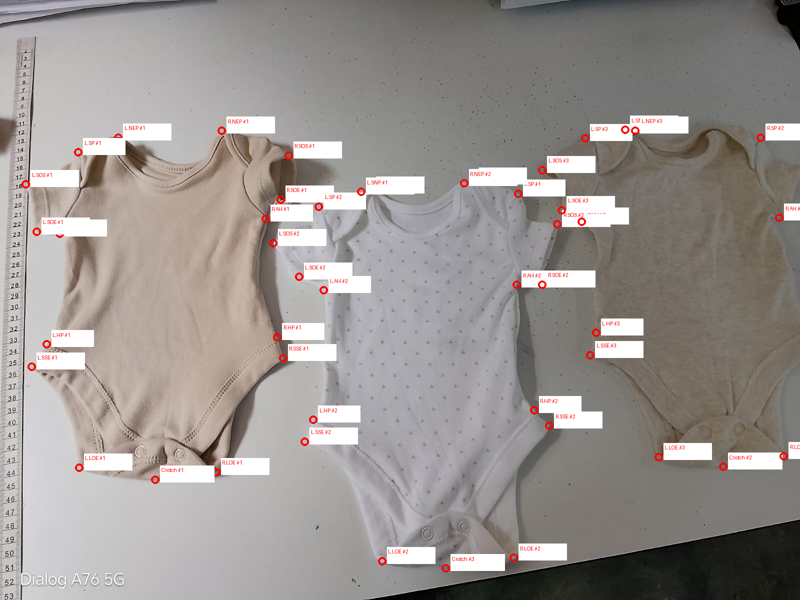

Saved: /content/453_annotations.jpg
Image size: 1600 x 1200


In [25]:
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
import os

image_path = "/content/GMAS_split/train/images/453_jpeg.rf.bb3P8stwEl6gCSwZBrBV.jpeg"
label_path = "/content/GMAS_split/train/labels/453_jpeg.rf.bb3P8stwEl6gCSwZBrBV.txt"

image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)

W, H = image.size

names = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 22)
except:
    font = ImageFont.load_default()

counter = {}

for line in open(label_path):
    parts = line.strip().split()

    if len(parts) < 5:
        continue

    cls = int(parts[0])
    x = float(parts[1]) * W
    y = float(parts[2]) * H

    name = names.get(cls, str(cls))

    counter[name] = counter.get(name, 0) + 1
    number = counter[name]

    r = 8

    draw.ellipse(
        [x-r, y-r, x+r, y+r],
        outline="red",
        width=4
    )

    label = f"{name} #{number}"

    draw.rectangle(
        [x + 10, y - 28, x + 10 + len(label) * 12, y + 5],
        fill="white"
    )

    draw.text(
        (x + 12, y - 25),
        label,
        fill="red",
        font=font
    )

output_path = "/content/453_annotations.jpg"
image.save(output_path)

display(image.resize((800, int(800 * H / W))))

print("Saved:", output_path)
print("Image size:", W, "x", H)

In [26]:
from ultralytics import YOLO
import math

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

image_path = "/content/410.jpeg"

results = model.predict(
    source=image_path,
    imgsz=1280,
    conf=0.10,
    device=0,
    verbose=False
)

names = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

points = {}

for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])

    if cls not in names:
        continue

    x = float(box.xywh[0][0])
    y = float(box.xywh[0][1])

    name = names[cls]

    if name not in points or conf > points[name]["conf"]:
        points[name] = {
            "x": x,
            "y": y,
            "conf": conf
        }

measurements = {
    "Back Neck Width": ("L.SNP", "R.SNP"),
    "Back Neck Edge Width": ("L.NEP", "R.NEP"),
    "Front Length": ("L.SNP", "Crotch"),
    "Left Sleeve Open": ("L.SOS", "L.SOE"),
    "Right Sleeve Open": ("R.SOS", "R.SOE"),
    "Left Sleeve Length": ("L.SP", "L.SOS"),
    "Right Sleeve Length": ("R.SP", "R.SOS"),
    "Left Side Seam": ("L.AH", "L.SSE"),
    "Right Side Seam": ("R.AH", "R.SSE"),
    "Left Leg Open": ("L.SSE", "L.LOE"),
    "Right Leg Open": ("R.SSE", "R.LOE"),
    "Chest": ("L.AH", "R.AH"),
    "Hip": ("L.SSE", "R.SSE")
}

print("=" * 70)
print("DETECTED POINTS")
print("=" * 70)

for name, p in points.items():
    print(
        f"{name:20s} "
        f"X={p['x']:8.1f} "
        f"Y={p['y']:8.1f} "
        f"Conf={p['conf']:.3f}"
    )

print("\n" + "=" * 70)
print("AVAILABLE MEASUREMENTS")
print("=" * 70)

for measurement, pair in measurements.items():

    p1, p2 = pair

    if p1 in points and p2 in points:

        x1, y1 = points[p1]["x"], points[p1]["y"]
        x2, y2 = points[p2]["x"], points[p2]["y"]

        pixel_distance = math.sqrt(
            (x2 - x1) ** 2 +
            (y2 - y1) ** 2
        )

        print(
            f"{measurement:25s} "
            f"{pixel_distance:10.2f} pixels "
            f"({p1} -> {p2})"
        )

    else:

        missing = []

        if p1 not in points:
            missing.append(p1)

        if p2 not in points:
            missing.append(p2)

        print(
            f"{measurement:25s} "
            f"NOT AVAILABLE "
            f"Missing: {', '.join(missing)}"
        )

DETECTED POINTS
R.SSE                X=  1068.0 Y=  1095.0 Conf=0.581
L.SOE                X=  1111.2 Y=   552.8 Conf=0.365
R.SOS                X=  1143.8 Y=   340.7 Conf=0.325
R.SOE                X=  1110.5 Y=   553.2 Conf=0.260
L.SOS                X=   117.8 Y=  1023.8 Conf=0.241
L.LOE                X=   298.2 Y=  1503.9 Conf=0.186
L.AH                 X=  1023.4 Y=   587.9 Conf=0.179
R.SP                 X=   996.6 Y=   215.9 Conf=0.150
L.HP                 X=  1031.7 Y=  1026.4 Conf=0.134

AVAILABLE MEASUREMENTS
Back Neck Width           NOT AVAILABLE Missing: L.SNP, R.SNP
Back Neck Edge Width      NOT AVAILABLE Missing: L.NEP, R.NEP
Front Length              NOT AVAILABLE Missing: L.SNP, Crotch
Left Sleeve Open             1099.46 pixels (L.SOS -> L.SOE)
Right Sleeve Open             215.13 pixels (R.SOS -> R.SOE)
Left Sleeve Length        NOT AVAILABLE Missing: L.SP
Right Sleeve Length           192.98 pixels (R.SP -> R.SOS)
Left Side Seam            NOT AVAILABLE Missing: L.

In [27]:
import gradio as gr
from ultralytics import YOLO
import math
import pandas as pd

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

names = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

measurements = {
    "Back Neck Width": ("L.SNP", "R.SNP"),
    "Back Neck Edge Width": ("L.NEP", "R.NEP"),
    "Front Length": ("L.SNP", "Crotch"),
    "Left Sleeve Open": ("L.SOS", "L.SOE"),
    "Right Sleeve Open": ("R.SOS", "R.SOE"),
    "Left Sleeve Length": ("L.SP", "L.SOS"),
    "Right Sleeve Length": ("R.SP", "R.SOS"),
    "Left Side Seam": ("L.AH", "L.SSE"),
    "Right Side Seam": ("R.AH", "R.SSE"),
    "Left Leg Open": ("L.SSE", "L.LOE"),
    "Right Leg Open": ("R.SSE", "R.LOE"),
    "Chest": ("L.AH", "R.AH"),
    "Hip": ("L.SSE", "R.SSE")
}

def measure_garment(image, confidence):

    if image is None:
        return None, pd.DataFrame(), "Please upload a garment image."

    results = model.predict(
        source=image,
        imgsz=1280,
        conf=confidence,
        device=0,
        verbose=False,
        max_det=100
    )

    result = results[0]

    points = {}

    for box in result.boxes:

        cls = int(box.cls[0])
        conf_value = float(box.conf[0])

        if cls not in names:
            continue

        x = float(box.xywh[0][0])
        y = float(box.xywh[0][1])

        name = names[cls]

        if name not in points or conf_value > points[name]["conf"]:
            points[name] = {
                "x": x,
                "y": y,
                "conf": conf_value
            }

    annotated = result.plot()

    rows = []

    for measurement, pair in measurements.items():

        p1, p2 = pair

        if p1 in points and p2 in points:

            x1 = points[p1]["x"]
            y1 = points[p1]["y"]

            x2 = points[p2]["x"]
            y2 = points[p2]["y"]

            distance = math.sqrt(
                (x2 - x1) ** 2 +
                (y2 - y1) ** 2
            )

            rows.append({
                "Measurement": measurement,
                "Point 1": p1,
                "Point 2": p2,
                "Value (pixels)": round(distance, 2),
                "Status": "Available"
            })

        else:

            missing = []

            if p1 not in points:
                missing.append(p1)

            if p2 not in points:
                missing.append(p2)

            rows.append({
                "Measurement": measurement,
                "Point 1": p1,
                "Point 2": p2,
                "Value (pixels)": "-",
                "Status": "Missing: " + ", ".join(missing)
            })

    detected_rows = []

    for name, p in points.items():

        detected_rows.append({
            "Point": name,
            "X": round(p["x"], 1),
            "Y": round(p["y"], 1),
            "Confidence": round(p["conf"], 3)
        })

    measurement_df = pd.DataFrame(rows)

    point_df = pd.DataFrame(detected_rows)

    summary = (
        f"Detected points: {len(points)} / 19\n"
        f"Available measurements: "
        f"{sum(measurement_df['Status'] == 'Available')} / {len(measurement_df)}"
    )

    return annotated, measurement_df, summary


with gr.Blocks(title="GMAS Measurement System") as app:

    gr.Markdown(
        """
        # GMAS – Automated Garment Measurement
        ### Detect garment points and calculate available measurements
        """
    )

    with gr.Row():

        with gr.Column():

            image_input = gr.Image(
                type="numpy",
                label="Upload Garment Image"
            )

            confidence = gr.Slider(
                minimum=0.01,
                maximum=0.80,
                value=0.10,
                step=0.01,
                label="Detection Confidence"
            )

            measure_button = gr.Button(
                "Detect & Measure",
                variant="primary"
            )

        with gr.Column():

            output_image = gr.Image(
                label="Detected Garment Points"
            )

            summary = gr.Textbox(
                label="Detection Summary"
            )

    measurement_table = gr.Dataframe(
        headers=[
            "Measurement",
            "Point 1",
            "Point 2",
            "Value (pixels)",
            "Status"
        ],
        label="Available Measurements",
        interactive=False
    )

    measure_button.click(
        fn=measure_garment,
        inputs=[
            image_input,
            confidence
        ],
        outputs=[
            output_image,
            measurement_table,
            summary
        ]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b9ba37d6a62cf2676.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [28]:
import gradio as gr
from ultralytics import YOLO
import math
import pandas as pd
import cv2
import numpy as np

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

names = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

measurements = {
    "Back Neck Width": ("L.SNP", "R.SNP"),
    "Back Neck Edge Width": ("L.NEP", "R.NEP"),
    "Front Length": ("L.SNP", "Crotch"),
    "Left Sleeve Open": ("L.SOS", "L.SOE"),
    "Right Sleeve Open": ("R.SOS", "R.SOE"),
    "Left Sleeve Length": ("L.SP", "L.SOS"),
    "Right Sleeve Length": ("R.SP", "R.SOS"),
    "Left Side Seam": ("L.AH", "L.SSE"),
    "Right Side Seam": ("R.AH", "R.SSE"),
    "Left Leg Open": ("L.SSE", "L.LOE"),
    "Right Leg Open": ("R.SSE", "R.LOE"),
    "Chest": ("L.AH", "R.AH"),
    "Hip": ("L.SSE", "R.SSE")
}

def measure_garment(image, confidence, reference_cm, reference_measurement):

    if image is None:
        return None, pd.DataFrame(), "Please upload a garment image."

    results = model.predict(
        source=image,
        imgsz=1280,
        conf=confidence,
        device=0,
        verbose=False,
        max_det=100
    )

    result = results[0]

    points = {}

    for box in result.boxes:

        cls = int(box.cls[0])
        conf_value = float(box.conf[0])

        if cls not in names:
            continue

        x = float(box.xywh[0][0])
        y = float(box.xywh[0][1])

        name = names[cls]

        if name not in points or conf_value > points[name]["conf"]:
            points[name] = {
                "x": x,
                "y": y,
                "conf": conf_value
            }

    output = image.copy()

    if output.dtype != np.uint8:
        output = np.clip(output, 0, 255).astype(np.uint8)

    output = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)

    for name, p in points.items():

        x = int(p["x"])
        y = int(p["y"])

        cv2.circle(
            output,
            (x, y),
            8,
            (0, 0, 255),
            -1
        )

        cv2.putText(
            output,
            name,
            (x + 10, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 0, 255),
            2
        )

    reference_pixels = None

    if reference_measurement in measurements:

        p1, p2 = measurements[reference_measurement]

        if p1 in points and p2 in points:

            x1 = points[p1]["x"]
            y1 = points[p1]["y"]

            x2 = points[p2]["x"]
            y2 = points[p2]["y"]

            reference_pixels = math.sqrt(
                (x2 - x1) ** 2 +
                (y2 - y1) ** 2
            )

    pixels_per_cm = None

    if reference_pixels is not None and reference_cm > 0:
        pixels_per_cm = reference_pixels / reference_cm

    rows = []

    for measurement, pair in measurements.items():

        p1, p2 = pair

        if p1 in points and p2 in points:

            x1 = points[p1]["x"]
            y1 = points[p1]["y"]

            x2 = points[p2]["x"]
            y2 = points[p2]["y"]

            pixel_distance = math.sqrt(
                (x2 - x1) ** 2 +
                (y2 - y1) ** 2
            )

            cm_value = "-"

            if pixels_per_cm is not None:
                cm_value = round(
                    pixel_distance / pixels_per_cm,
                    2
                )

            cv2.line(
                output,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (255, 0, 0),
                4
            )

            mid_x = int((x1 + x2) / 2)
            mid_y = int((y1 + y2) / 2)

            label = f"{measurement}: {cm_value} cm"

            if cm_value == "-":
                label = f"{measurement}: {pixel_distance:.1f}px"

            cv2.putText(
                output,
                label,
                (mid_x, mid_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (255, 0, 0),
                2
            )

            rows.append({
                "Measurement": measurement,
                "Point 1": p1,
                "Point 2": p2,
                "Pixels": round(pixel_distance, 2),
                "CM": cm_value,
                "Status": "Available"
            })

        else:

            missing = []

            if p1 not in points:
                missing.append(p1)

            if p2 not in points:
                missing.append(p2)

            rows.append({
                "Measurement": measurement,
                "Point 1": p1,
                "Point 2": p2,
                "Pixels": "-",
                "CM": "-",
                "Status": "Missing: " + ", ".join(missing)
            })

    output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

    if pixels_per_cm is not None:

        summary = (
            f"Detected points: {len(points)} / 19\n"
            f"Available measurements: "
            f"{sum(r['Status'] == 'Available' for r in rows)} / {len(rows)}\n"
            f"Reference: {reference_measurement} = {reference_cm} cm\n"
            f"Scale: {pixels_per_cm:.2f} pixels/cm"
        )

    else:

        summary = (
            f"Detected points: {len(points)} / 19\n"
            f"Available measurements: "
            f"{sum(r['Status'] == 'Available' for r in rows)} / {len(rows)}\n"
            f"CM conversion not available"
        )

    return output, pd.DataFrame(rows), summary


with gr.Blocks(title="GMAS Measurement System") as app:

    gr.Markdown(
        """
        # GMAS – Automated Garment Measurement
        ### Detect points and calculate garment measurements
        """
    )

    with gr.Row():

        with gr.Column():

            image_input = gr.Image(
                type="numpy",
                label="Garment Image"
            )

            confidence = gr.Slider(
                minimum=0.01,
                maximum=0.80,
                value=0.10,
                step=0.01,
                label="Detection Confidence"
            )

            reference_measurement = gr.Dropdown(
                choices=list(measurements.keys()),
                value="Chest",
                label="Known Reference Measurement"
            )

            reference_cm = gr.Number(
                value=30,
                label="Known Reference Value (cm)"
            )

            measure_button = gr.Button(
                "Detect & Measure",
                variant="primary"
            )

        with gr.Column():

            output_image = gr.Image(
                label="Garment With Measurements"
            )

            summary = gr.Textbox(
                label="Detection Summary"
            )

    measurement_table = gr.Dataframe(
        label="Measurements",
        interactive=False
    )

    measure_button.click(
        fn=measure_garment,
        inputs=[
            image_input,
            confidence,
            reference_cm,
            reference_measurement
        ],
        outputs=[
            output_image,
            measurement_table,
            summary
        ]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b8ce0054444567214.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [29]:
import gradio as gr
from ultralytics import YOLO
import math
import pandas as pd
import cv2
import numpy as np

model = YOLO("/content/GMAS_training/gmas_keypoint_v1/weights/best.pt")

names = {
    0: "Crotch",
    3: "L.AH",
    9: "L.HP",
    10: "L.LOE",
    11: "L.NEP",
    12: "L.SNP",
    13: "L.SOE",
    14: "L.SOS",
    15: "L.SP",
    16: "L.SSE",
    18: "R.AH",
    24: "R.HP",
    25: "R.LOE",
    26: "R.NEP",
    27: "R.SNP",
    28: "R.SOE",
    29: "R.SOS",
    30: "R.SP",
    31: "R.SSE"
}

measurements = {
    "Back Neck Width": ("L.SNP", "R.SNP"),
    "Back Neck Edge Width": ("L.NEP", "R.NEP"),
    "Front Length": ("L.SNP", "Crotch"),
    "Left Sleeve Open": ("L.SOS", "L.SOE"),
    "Right Sleeve Open": ("R.SOS", "R.SOE"),
    "Left Sleeve Length": ("L.SP", "L.SOS"),
    "Right Sleeve Length": ("R.SP", "R.SOS"),
    "Left Side Seam": ("L.AH", "L.SSE"),
    "Right Side Seam": ("R.AH", "R.SSE"),
    "Left Leg Open": ("L.SSE", "L.LOE"),
    "Right Leg Open": ("R.SSE", "R.LOE"),
    "Chest": ("L.AH", "R.AH"),
    "Hip": ("L.SSE", "R.SSE")
}

def measure_garment(image, confidence, reference_cm, reference_measurement):

    if image is None:
        return None, pd.DataFrame(), "Please upload a garment image."

    results = model.predict(
        source=image,
        imgsz=1280,
        conf=confidence,
        device=0,
        verbose=False,
        max_det=100
    )

    result = results[0]

    points = {}

    for box in result.boxes:

        cls = int(box.cls[0])
        conf_value = float(box.conf[0])

        if cls not in names:
            continue

        x = float(box.xywh[0][0])
        y = float(box.xywh[0][1])

        name = names[cls]

        if name not in points or conf_value > points[name]["conf"]:
            points[name] = {
                "x": x,
                "y": y,
                "conf": conf_value
            }

    output = image.copy()

    if output.dtype != np.uint8:
        output = np.clip(output, 0, 255).astype(np.uint8)

    output = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)

    for name, p in points.items():

        x = int(p["x"])
        y = int(p["y"])

        cv2.circle(
            output,
            (x, y),
            8,
            (0, 0, 255),
            -1
        )

        cv2.putText(
            output,
            name,
            (x + 10, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 0, 255),
            2
        )

    reference_pixels = None

    if reference_measurement in measurements:

        p1, p2 = measurements[reference_measurement]

        if p1 in points and p2 in points:

            x1 = points[p1]["x"]
            y1 = points[p1]["y"]

            x2 = points[p2]["x"]
            y2 = points[p2]["y"]

            reference_pixels = math.sqrt(
                (x2 - x1) ** 2 +
                (y2 - y1) ** 2
            )

    pixels_per_cm = None

    if reference_pixels is not None and reference_cm > 0:
        pixels_per_cm = reference_pixels / reference_cm

    rows = []

    for measurement, pair in measurements.items():

        p1, p2 = pair

        if p1 in points and p2 in points:

            x1 = points[p1]["x"]
            y1 = points[p1]["y"]

            x2 = points[p2]["x"]
            y2 = points[p2]["y"]

            pixel_distance = math.sqrt(
                (x2 - x1) ** 2 +
                (y2 - y1) ** 2
            )

            cm_value = "-"

            if pixels_per_cm is not None:
                cm_value = round(
                    pixel_distance / pixels_per_cm,
                    2
                )

            cv2.line(
                output,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (255, 0, 0),
                4
            )

            mid_x = int((x1 + x2) / 2)
            mid_y = int((y1 + y2) / 2)

            label = f"{measurement}: {cm_value} cm"

            if cm_value == "-":
                label = f"{measurement}: {pixel_distance:.1f}px"

            cv2.putText(
                output,
                label,
                (mid_x, mid_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (255, 0, 0),
                2
            )

            rows.append({
                "Measurement": measurement,
                "Point 1": p1,
                "Point 2": p2,
                "Pixels": round(pixel_distance, 2),
                "CM": cm_value,
                "Status": "Available"
            })

        else:

            missing = []

            if p1 not in points:
                missing.append(p1)

            if p2 not in points:
                missing.append(p2)

            rows.append({
                "Measurement": measurement,
                "Point 1": p1,
                "Point 2": p2,
                "Pixels": "-",
                "CM": "-",
                "Status": "Missing: " + ", ".join(missing)
            })

    output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

    if pixels_per_cm is not None:

        summary = (
            f"Detected points: {len(points)} / 19\n"
            f"Available measurements: "
            f"{sum(r['Status'] == 'Available' for r in rows)} / {len(rows)}\n"
            f"Reference: {reference_measurement} = {reference_cm} cm\n"
            f"Scale: {pixels_per_cm:.2f} pixels/cm"
        )

    else:

        summary = (
            f"Detected points: {len(points)} / 19\n"
            f"Available measurements: "
            f"{sum(r['Status'] == 'Available' for r in rows)} / {len(rows)}\n"
            f"CM conversion not available"
        )

    return output, pd.DataFrame(rows), summary


with gr.Blocks(title="GMAS Measurement System") as app:

    gr.Markdown(
        """
        # GMAS – Automated Garment Measurement
        ### Detect points and calculate garment measurements
        """
    )

    with gr.Row():

        with gr.Column():

            image_input = gr.Image(
                type="numpy",
                label="Garment Image"
            )

            confidence = gr.Slider(
                minimum=0.01,
                maximum=0.80,
                value=0.10,
                step=0.01,
                label="Detection Confidence"
            )

            reference_measurement = gr.Dropdown(
                choices=list(measurements.keys()),
                value="Chest",
                label="Known Reference Measurement"
            )

            reference_cm = gr.Number(
                value=30,
                label="Known Reference Value (cm)"
            )

            measure_button = gr.Button(
                "Detect & Measure",
                variant="primary"
            )

        with gr.Column():

            output_image = gr.Image(
                label="Garment With Measurements"
            )

            summary = gr.Textbox(
                label="Detection Summary"
            )

    measurement_table = gr.Dataframe(
        label="Measurements",
        interactive=False
    )

    measure_button.click(
        fn=measure_garment,
        inputs=[
            image_input,
            confidence,
            reference_cm,
            reference_measurement
        ],
        outputs=[
            output_image,
            measurement_table,
            summary
        ]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://34dbe4902e078d81bc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
